# Ultimate Attribute Opening Examples

This notebook demonstrates Ultimate Attribute Opening (UAO) workflows with `mmcfilters`. It builds attribute-opening primitive families, visualizes selected primitives, and reconstructs filtered images from the associated tree information.


In [1]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


def create_component_tree(image, is_maxtree, radius=1.5):
    if is_maxtree:
        return mmcfilters.WeightedMorphologicalTree.createMaxTree(image, radius=radius)
    return mmcfilters.WeightedMorphologicalTree.createMinTree(image, radius=radius)


## Load the input image

The examples use a grayscale image so max-tree attributes can be interpreted directly against image intensity and component geometry.


In [2]:
#input_image = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
input_image = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#input_image = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = input_image.shape

#plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
#plt.title('input')

## Build the tree and compute the criterion attribute

UAO needs a component tree and a criterion attribute. Here the box-height attribute drives the primitive family and the associated reconstruction.


In [3]:
tree = mmcfilters.WeightedMorphologicalTree.createMaxTree(input_image, radius=1.5)
attribute_indices, attribute_matrix = mmcfilters.Attribute.computeAttributes(tree, [mmcfilters.Attribute.Type.BOX_HEIGHT])
node_attribute = attribute_matrix[:, attribute_indices['BOX_HEIGHT']]

## Create an attribute-opening primitive family

The primitive family stores how the image changes across increasing attribute thresholds. The MSER delta controls the stability window used to select meaningful primitives.


In [4]:
mser_delta=19
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(tree, node_attribute, num_rows, mser_delta)

In [5]:
thresholds = primitives.getThresholdsPrimitive()
num_primitives_to_display = 8
thresholds_to_display = np.array(thresholds, dtype=int)[np.linspace(0, len(thresholds)-1, num_primitives_to_display, dtype=int)]
primitives.numPrimitives, len(thresholds), thresholds_to_display

(21671, 169, array([  1,  25,  49,  74, 102, 139, 204, 863]))

## Inspect selected primitives

The threshold list below chooses representative primitive levels. Plotting each primitive helps verify whether the selected attribute scale isolates the expected structures.


Text(0.5, 1.0, 'restOfImage')

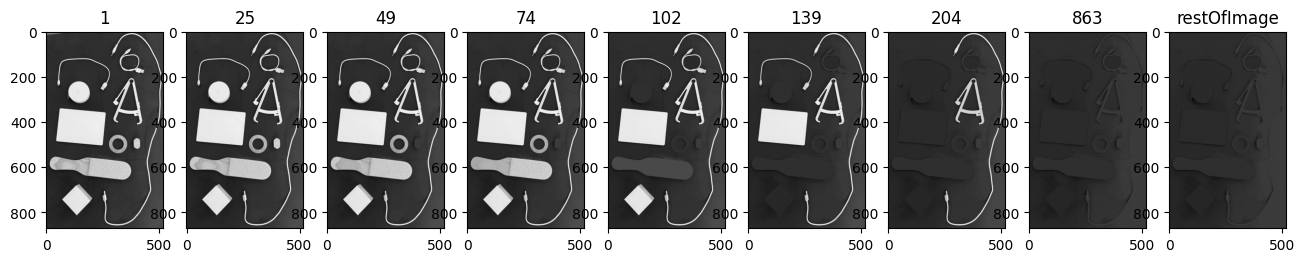

In [6]:
i = 0
for threshold in thresholds_to_display:
    i += 1
    plt.subplot(1,len(thresholds_to_display)+1, i)
    primitive = primitives.getPrimitive(threshold) 
    plt.imshow(primitive.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
    plt.title(str(int(threshold)))

rest = primitives.restOfImage
plt.subplot(1,len(thresholds_to_display)+1, len(thresholds_to_display)+1)
plt.imshow(rest.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('restOfImage')

Text(0.5, 1.0, 'restOfImage')

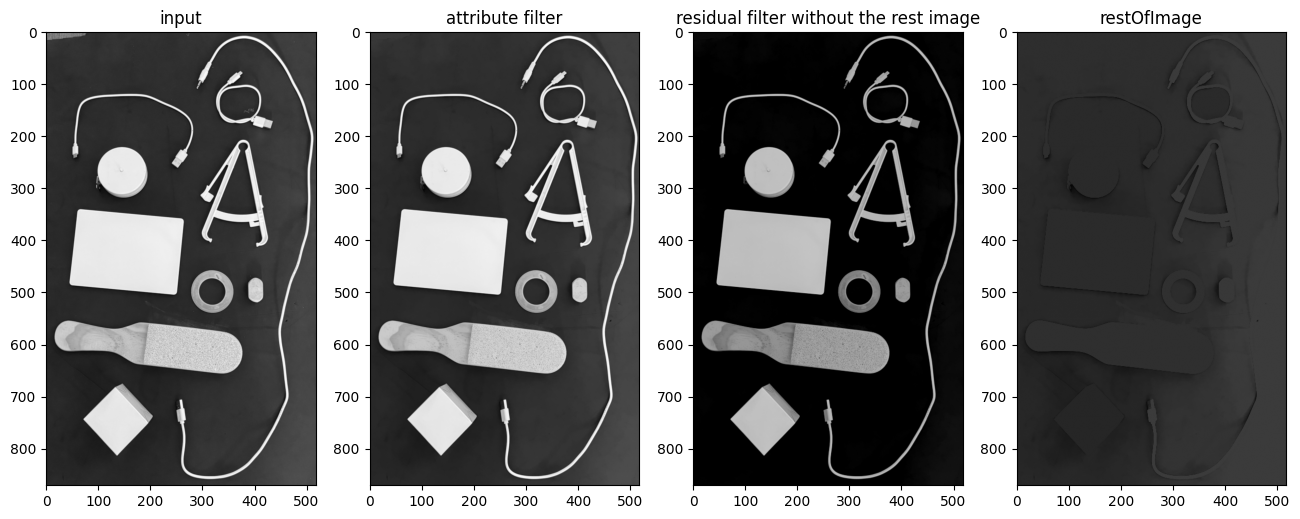

In [7]:
node_attribute = attribute_matrix[:, attribute_indices['BOX_HEIGHT']]
threshold = 20

attribute_filter = mmcfilters.AttributeFilters(tree)
attribute_filter_image = attribute_filter.filteringSubtractiveRule(node_attribute > threshold)
residual_filter_image = primitives.getPrimitive(threshold)
primitive_only_image = np.clip(
    residual_filter_image.astype(np.int16) - rest.astype(np.int16),
    0,
    255,
).astype(np.uint8)


plt.subplot(1,4, 1)
plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(attribute_filter_image.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')

plt.subplot(1,4, 3)
plt.imshow(primitive_only_image.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('residual filter without the rest image')

plt.subplot(1,4, 4)
plt.imshow(rest.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('restOfImage')

## Reconstruct and compare filtered images

The associated image gives the UAO reconstruction, while the primitive-only view makes it easier to inspect which structures were selected by the primitive family.


Text(0.5, 1.0, 'attribute filter')

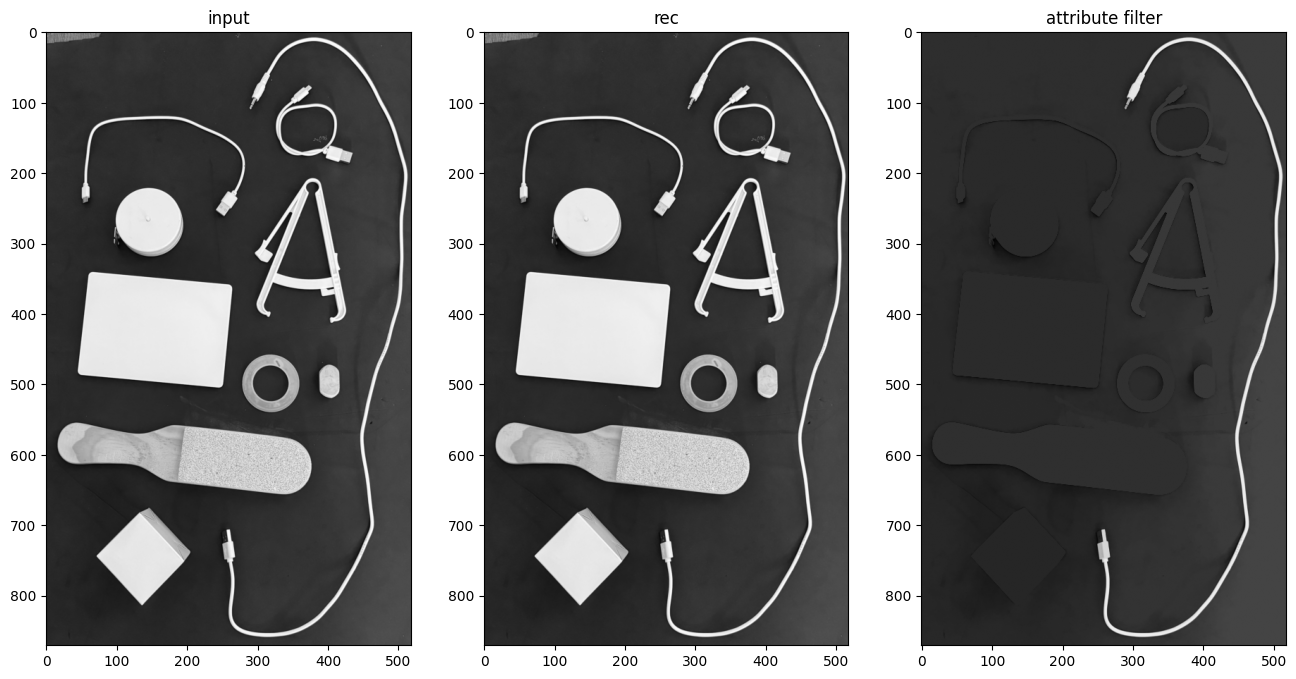

In [8]:
reconstructed_image = tree.reconstructionImage() 
filtered_image = attribute_filter.filteringSubtractiveRule(node_attribute > 500)

plt.subplot(1,3, 1)
plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,3, 2)
plt.imshow(reconstructed_image.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('rec')

plt.subplot(1,3, 3)
plt.imshow(filtered_image.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')


#np.sum(input_image.ravel() - reconstructed_image)

## Execute UAO directly

`UltimateAttributeOpening` wraps the primitive-family workflow and returns associated attributes and saliency information for the selected criterion.


Text(0.5, 1.0, 'associated')

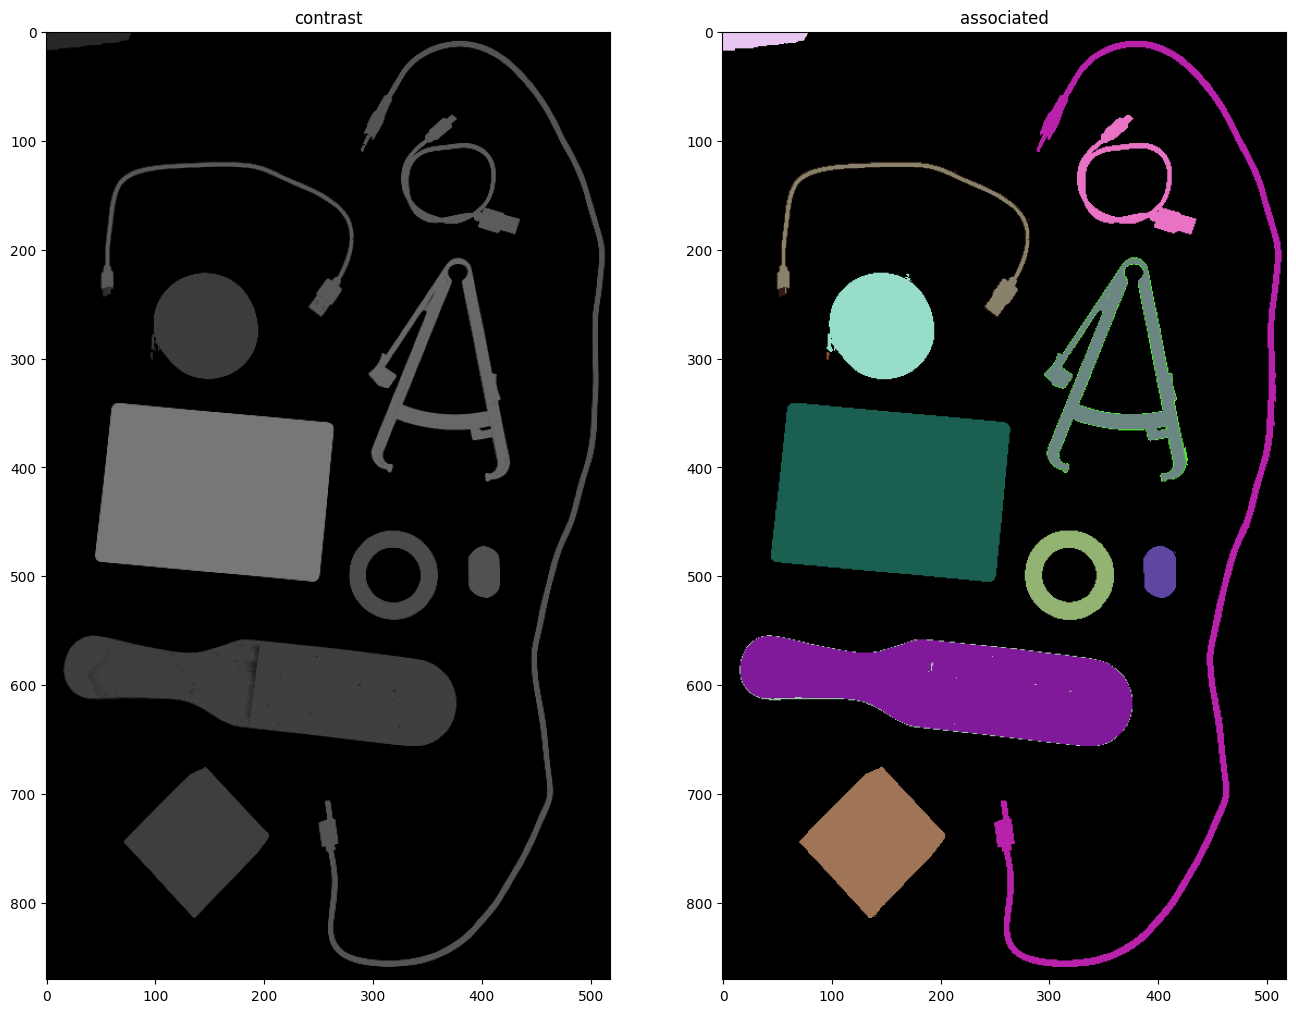

In [9]:
uao = mmcfilters.UltimateAttributeOpening(tree, node_attribute)
uao.executeWithMSER(num_rows, mser_delta)
roundtrip_contrast_image = uao.getMaxContrastImage()
roundtrip_associated_color_image = uao.getAssociatedColoredImage()

plt.subplot(1,2,1)
plt.imshow(roundtrip_contrast_image.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(roundtrip_associated_color_image.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

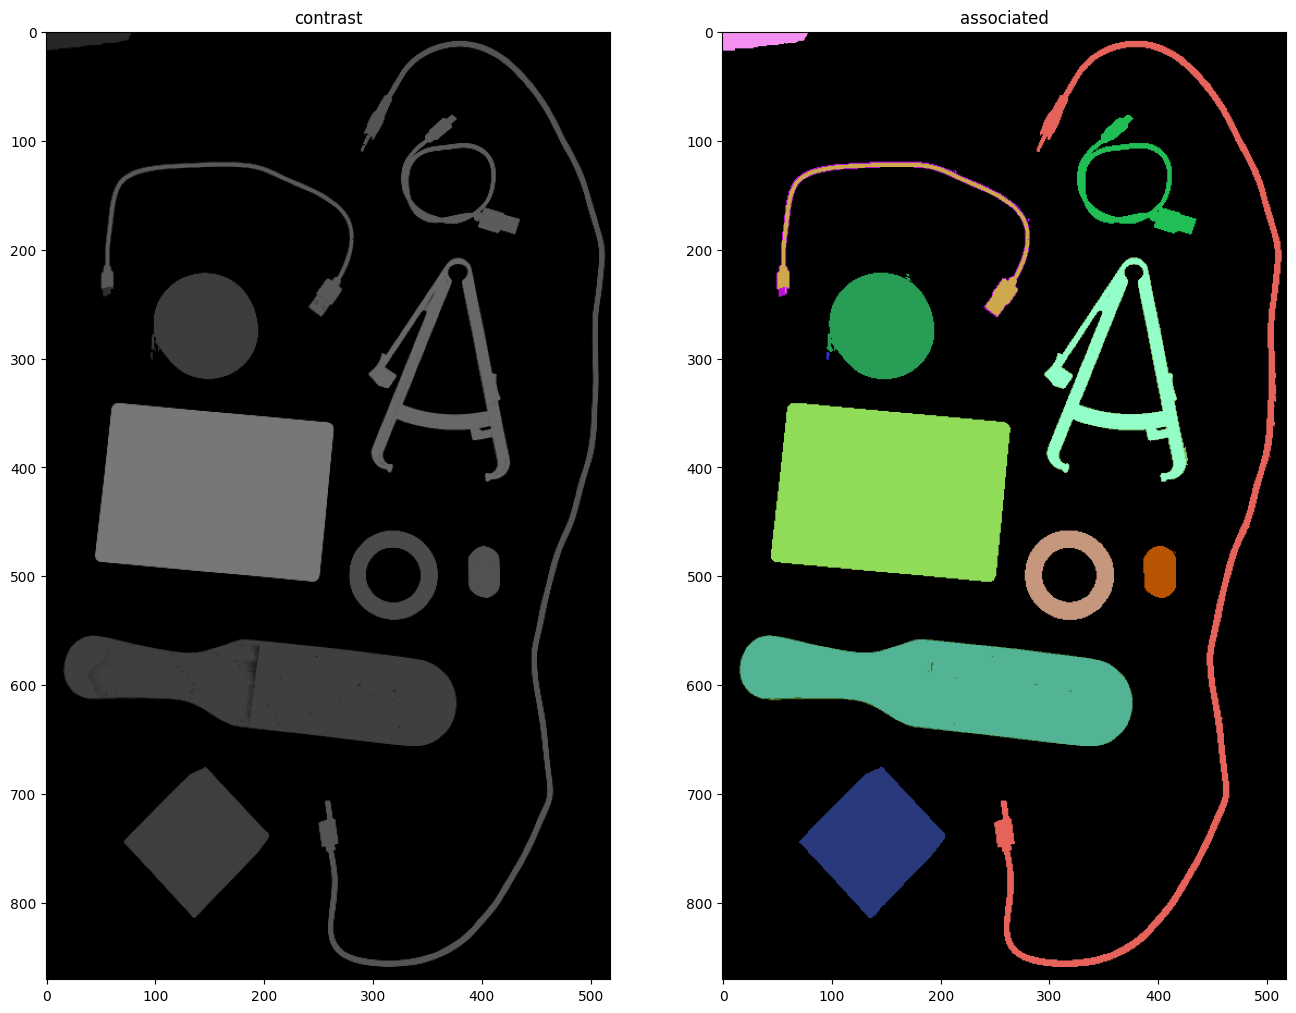

In [10]:
uao = mmcfilters.UltimateAttributeOpening(tree, node_attribute)

uao.executeWithMSER( num_rows, mser_delta )
associated_image = uao.getAssociatedColoredImage()
contrast_image = uao.getMaxContrastImage()

#import random
#colors = [ [random.randint(0, 255) for _ in range(3)] for _ in range(0, np.max(associated_image)+1)]
#rgb_contrast_image = [(0,0,0) if p == 0 else colors[p] for p in associated_image]

plt.subplot(1,2,1)
plt.imshow(contrast_image.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(np.array(associated_image).reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

In [11]:
np.sum(roundtrip_contrast_image - contrast_image)

np.uint64(0)

## Repeat the workflow on a second image

The same steps are repeated on another input to check that the chosen parameters and attribute criterion generalize beyond the first example.


Text(0.5, 1.0, 'associated')

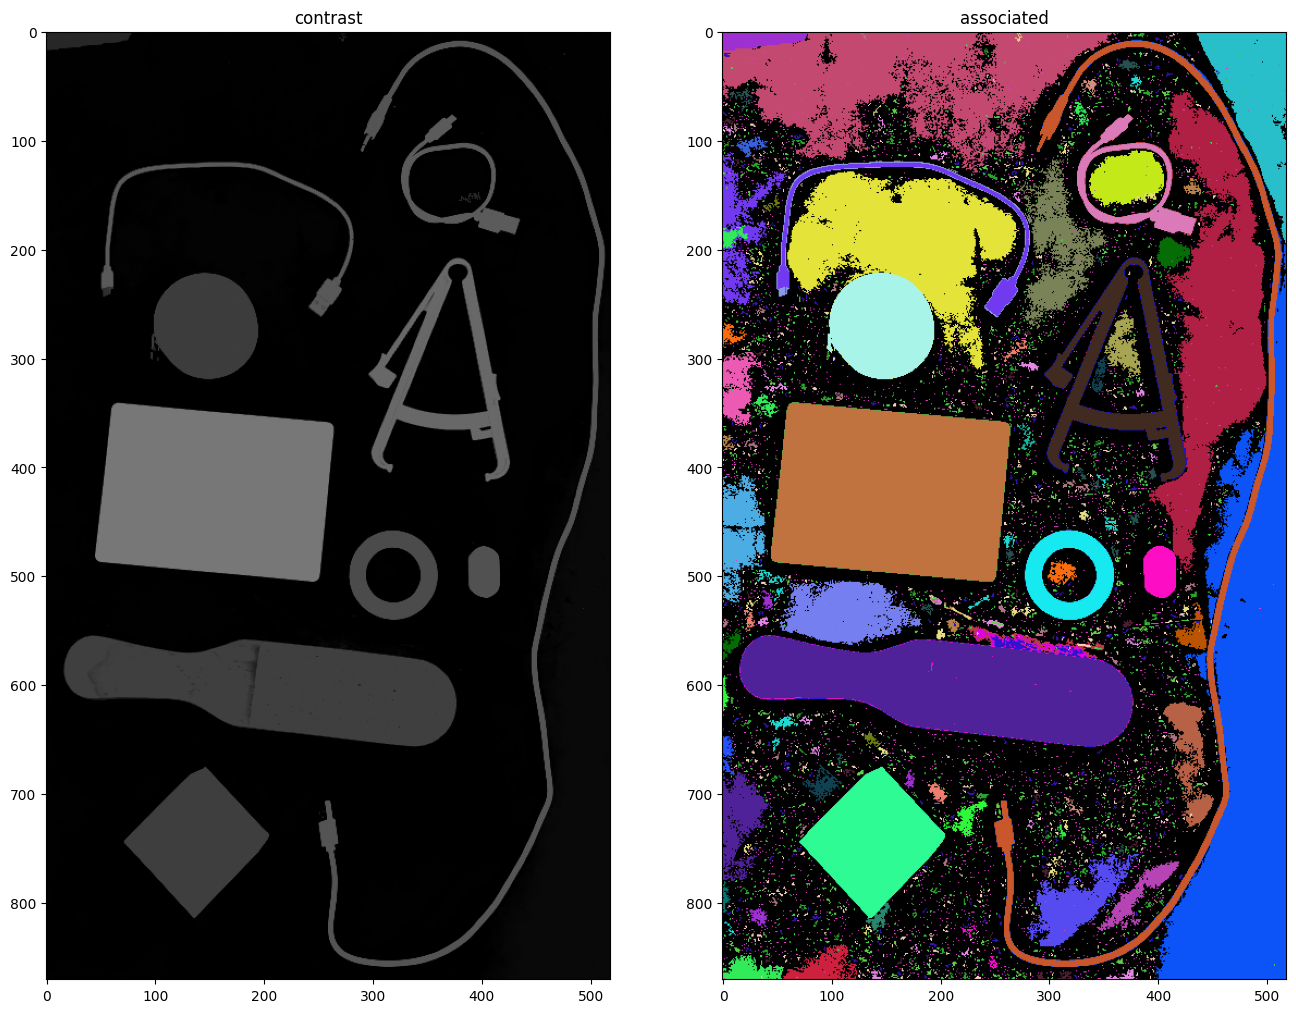

In [12]:
input_image = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
(num_rows, num_cols) = input_image.shape
tree = mmcfilters.WeightedMorphologicalTree.createMaxTree(input_image, radius=1.5)
attribute_indices, attribute_matrix = mmcfilters.Attribute.computeAttributes(tree, [mmcfilters.Attribute.Type.BOX_HEIGHT])

uao = mmcfilters.UltimateAttributeOpening(tree, attribute_matrix[:, attribute_indices['BOX_HEIGHT']])
uao.execute(num_rows - 1)
contrast_image = uao.getMaxContrastImage()
associated_color_image = uao.getAssociatedColoredImage()

plt.subplot(1,2,1)
plt.imshow(contrast_image.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(associated_color_image.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

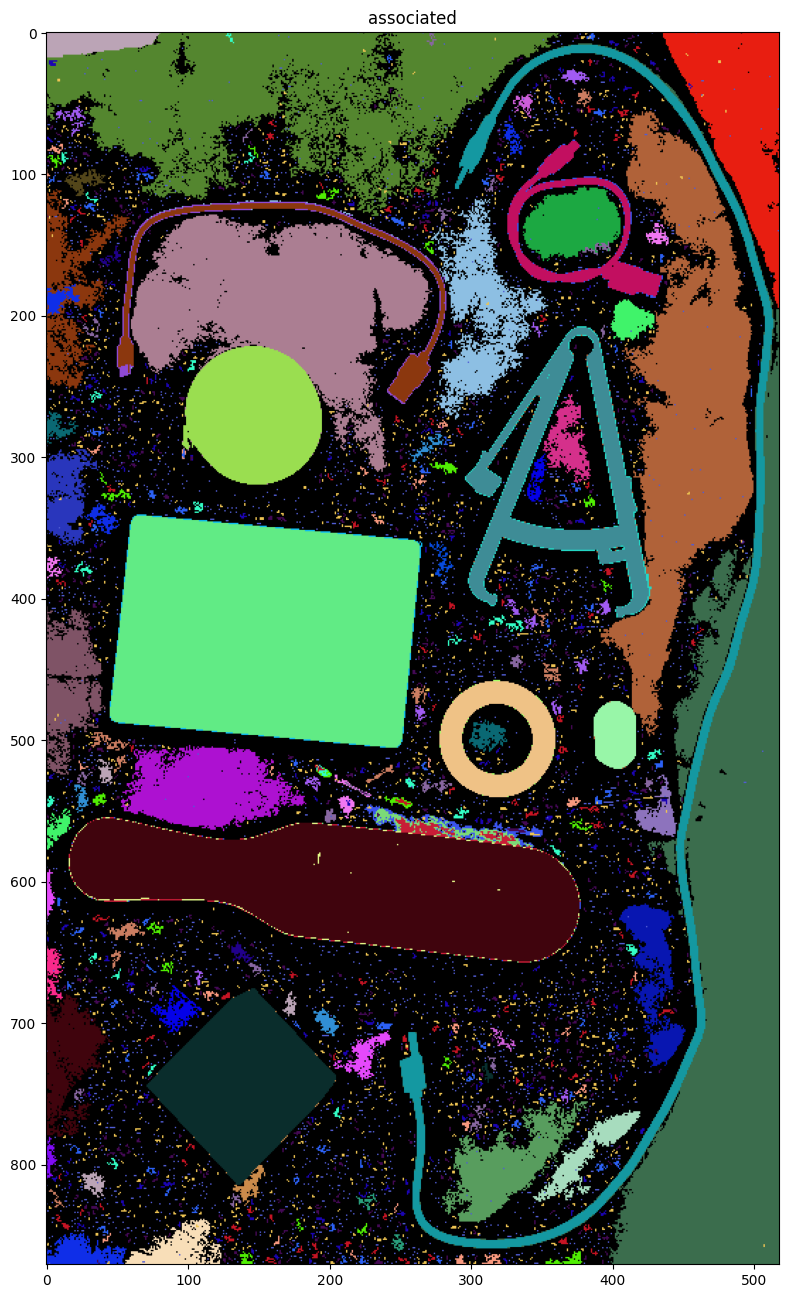

In [13]:
associated_image = uao.getAssociatedImage().ravel()

import random
colors = [[random.randint(0, 255) for _ in range(3)] for _ in range(0, int(np.max(associated_image)) + 1)]
rgb_contrast_image = [(0, 0, 0) if p == 0 else colors[int(p)] for p in associated_image]

plt.imshow(np.array(rgb_contrast_image).reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

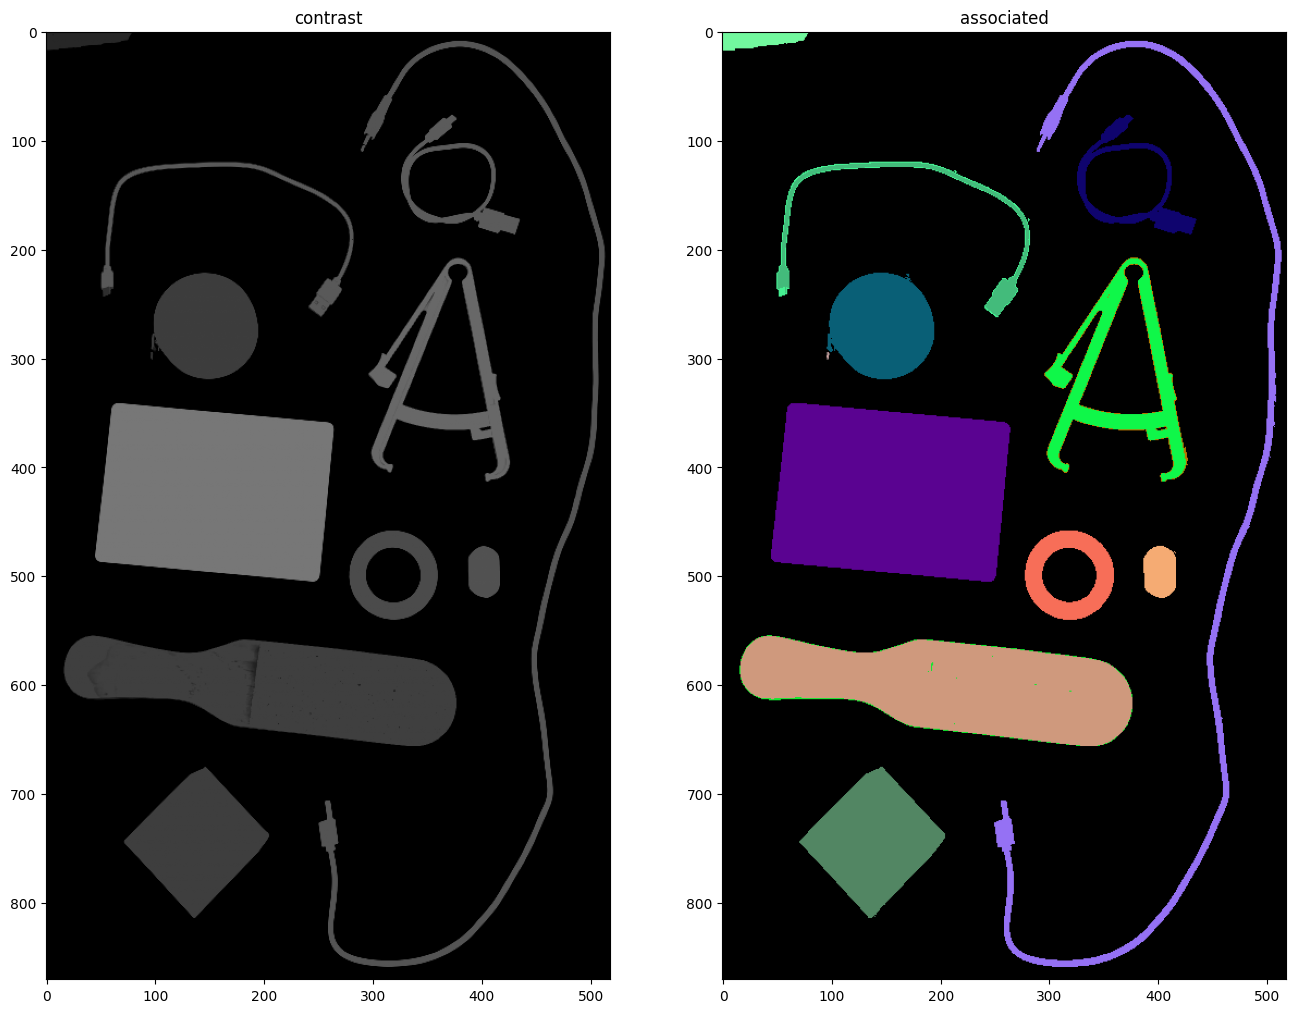

In [14]:
maxCriterion = num_rows
mser_delta = 20

uao.executeWithMSER( int(maxCriterion), mser_delta )
contrast_image = uao.getMaxContrastImage()
associated_color_image = uao.getAssociatedColoredImage()

plt.subplot(1,2,1)
plt.imshow(contrast_image.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(associated_color_image.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

In [15]:
np.min(associated_color_image), np.max(associated_color_image)

(np.uint8(0), np.uint8(248))

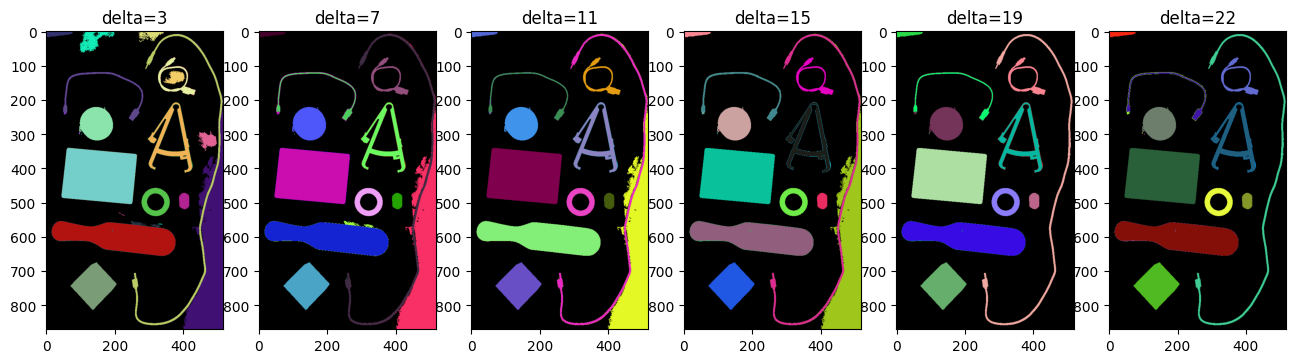

In [16]:
uao = mmcfilters.UltimateAttributeOpening(tree, attribute_matrix[:,attribute_indices['BOX_HEIGHT']])
maxCriterion = num_rows
line = 1
for i in range(1, 6+1):
    mser_delta = int(i*3.8)
    uao.executeWithMSER( int(maxCriterion), mser_delta )
    associated_color_image = uao.getAssociatedColoredImage()
        
    plt.subplot(line,6, i)
    plt.imshow(associated_color_image.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
    plt.title('delta=' + str(mser_delta))